In [57]:
import numpy as np
from scipy.stats import norm
# from cmblensplus/utils/
import constant as c
import binning as bn
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
from matplotlib.pyplot import *
cr = rcParams['axes.prop_cycle'].by_key()['color']

In [30]:
import importlib
importlib.reload(tools_delens)

<module 'tools_delens' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_delens.py'>

In [3]:
simN = 500
lbmin, lbmax = 2, 190
bN = 50
area = 'lbfull'
#method = 'bonly'

In [4]:
pobj = local.analysis()
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename(method='cinv')

In [5]:
mask = tools_cmb.prepare_masks()
Fsky = {m: np.average(mask[m]) for m in tools_cmb.masks}
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')
L = np.linspace(0,lbmax,lbmax+1)
fsky = Fsky[area]
print(fsky)

0.4831339


In [6]:
# range of r
rs = np.arange(-7e-3+40*5e-5,7e-3,5e-5)
x = 1e3*rs

In [8]:
Ob, Db, Rb = tools_delens.load_clbbs(dobj.cl[area]['klb'],mb,simN,fsky)

In [22]:
print(np.shape(Rb))

(500, 50)


In [37]:
hatr = {}
for rs in [0,0.001,0.005,0.01,0.02]:
    hatr[rs] = tools_delens.simple_r(Ob,Rb,rs)

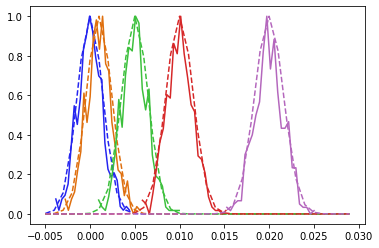

In [61]:
for i, rs in enumerate([0,0.001,0.005,0.01,0.02]):
    hatr_dist, edges = np.histogram(hatr[rs].flat, bins=25)
    binCenters = (edges[:-1] + edges[1:])/2
    hatr_dist = hatr_dist/np.max(hatr_dist) # norm the heights
    plot(binCenters, hatr_dist)
    rx = np.arange(-0.005,0.03,0.001)
    sigma = np.std(hatr[rs])
    pdf = norm.pdf(rx,loc=rs,scale=sigma)
    plot(rx,pdf/np.max(pdf),color=cr[i],ls='--')